# Identifying density levels reaching the shelf

I want to map out only the ocean heat transport that reaches the coast. That is because part of the heat transport crossing the 1km isobath (especially in the Ekman Layer), will reach the surface before actually reaching the shelf, and would not contribute to ice shelf melting. 

In [1]:
import cosima_cookbook as cc
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
from dask.distributed import Client
from scipy.interpolate import interp1d

import xarray as xr
import cf_xarray as cfxr
import glob
import gsw

In [2]:
client = Client(memory_limit='1300gb',n_workers=48)

#### Densities along 10 degree bins

Lets first look at the density in 10 degree, bins, is it feasible to locate the density right off the shelf? Frst testing for the coarser and lighter to load case, $0.1^o$

In [3]:
session = cc.database.create_session()
panan01_exp = 'panant-01-zstar-ACCESSyr2'
panan005_exp = 'panant-005-zstar-ACCESSyr2'
panan0025_exp = 'panant-0025-zstar-ACCESSyr2'

start_time = '1991-01'
end_time = '2000-12'
depth_slice= slice(0,1700)

In [4]:
%%time
#Importing panan_01 volcellos
volcello_01_ρ = cc.querying.getvar(panan01_exp,'volcello',session,ncfile='%month_rho2.n%',frequency='1 monthly',start_time=start_time,end_time=end_time,chunks={})\
.sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-60))
volcello_01_z = cc.querying.getvar(panan01_exp,'volcello',session,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time,chunks={'time':'1000gb'})\
.sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-60),z_l=depth_slice)
areacello_01 = cc.querying.getvar(panan01_exp,'areacello',session,n=1,chunks={}).sel(yh=slice(-90,-60))
areacello_01.load()
#importing panan rhopot2 in z*
ρ2_01_z = cc.querying.getvar(panan01_exp,'rhopot2',session,ncfile='%month_z.n%',frequency='1 monthly',start_time=start_time,end_time=end_time,\
                             chunks={'time':'1000gb'})\
.sel(time=slice(start_time,end_time)).sel(yh=slice(-90,-60),z_l=depth_slice)
ρ2_01_z.load()
volcello_01_z.load()
print('Loaded area and sigmas to the memory')

Loaded area and sigmas to the memory
CPU times: user 2min 2s, sys: 3min 8s, total: 5min 10s
Wall time: 4min 47s


Now, lets bin the densities into $10^o$ longitude bins

In [5]:
#creating the bin edges
areacello_01 = areacello_01.where(ρ2_01_z.isel(time=0,z_l=0).drop(('time','z_l')).fillna(0)!=0)
lon_bin=10
bin_edges = np.arange(-280, 85, lon_bin)

lon_bin_mid = np.arange((bin_edges[0]+(lon_bin/2)),(bin_edges[-1]+(lon_bin/2)),lon_bin) # for 10-deg bins

In [6]:
#binned area
volcello_01_z_t0=volcello_01_z.isel(time=0).drop('time')
volcello_01_z_10deg = volcello_01_z_t0.groupby_bins('xh',bins=bin_edges).sum()

#Binned average densities
ρ2_01_z_10deg = (ρ2_01_z * volcello_01_z_t0).groupby_bins('xh',bins=bin_edges).sum()/volcello_01_z_10deg


Sanity check

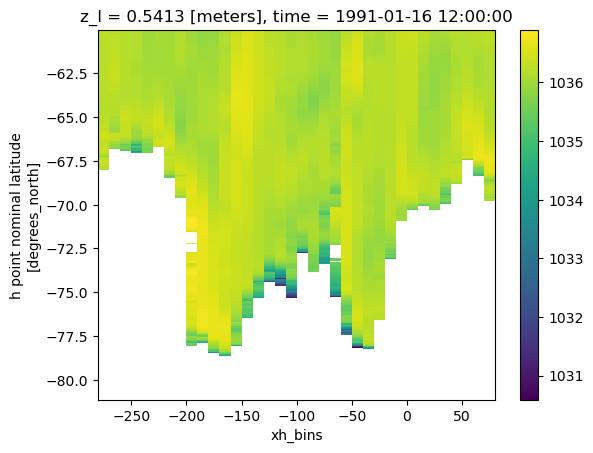

In [8]:
ρ2_01_z_10deg.isel(time=0,z_l=0).plot()

Seems reasonable to me...



Now let's define the computational approach to map out the depth of isopycnals on the shelf. For that we will...

1- for each depth, will will cumsum the densities from north to south.

2-For each lon bin, let's extract lat index of the maximum cumsumed density

3- that comunation of depth and latmax should be mapping the coastal densities.


In [73]:
# GEtting the southermost ocean point in each depth, and each lon_bin
ρ2_01_z_10deg_yhcumsum = ρ2_01_z_10deg.ffill(dim='yh').isel(time=0)[:,::-1,:].cumsum('yh', skipna=False)[:,::-1,:]


coastline_y_z = ρ2_01_z_10deg_yhcumsum.yh[ρ2_01_z_10deg_yhcumsum.argmax('yh')]

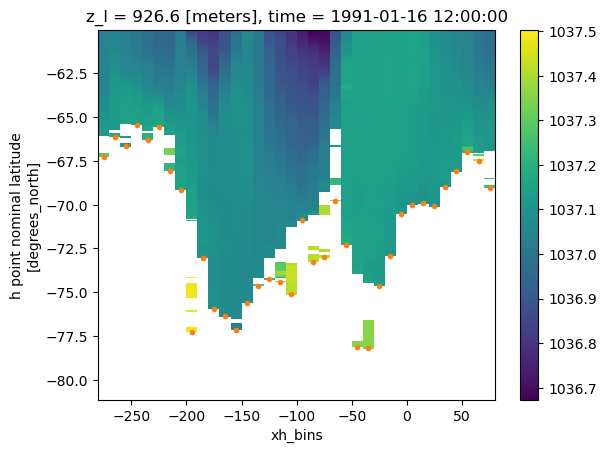

In [85]:
#does it work? let's test for different depths
Zind=-7
ρ2_01_z_10deg.isel(time=0,z_l=Zind).plot()
plt.plot(lon_bin_mid,coastline_y_z.isel(z_l=Zind),'.',color='tab:orange')

Doest it make sense to chose those points? Continue by evaluating this question next time